# Figure 4: Multiple occluders

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
%run env_aws.py
%run run.py connect

2025-04-23 11:22:36,244::INFO::settings.py::Setting loglevel to INFO
2025-04-23 11:22:36,246::INFO::settings.py::Setting stores to {}
2025-04-23 11:22:36,247::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-04-23 11:22:36,249::INFO::settings.py::Setting database.misc.create_tables to True
2025-04-23 11:22:36,251::INFO::settings.py::Setting enable_python_native_blobs to True
2025-04-23 11:22:36,252::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-04-23 11:22:36,253::INFO::settings.py::Setting database.user to thomas
2025-04-23 11:22:36,254::INFO::settings.py::Setting database.password to thomas_mathislab
2025-04-23 11:22:36,410::INFO::connection.py::Connected thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting thomas@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-04-23 11:22:36,528::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:36,969::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:36,969::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:37,472::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:37,472::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:37,632::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:37,632::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:37,970::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:37,970::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:38,334::INFO::table.py::could not log event in table ~log
2025-04-23 11:22:38,334::INFO::table.py::could not log event in table ~log


In [44]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc, vr4mice
from vr4mice.analysis import utils


from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [21]:
multi_occluder_tolias =(vr4mice.Dataset() & 'dataset LIKE "%31728%" AND session_label = "ar_discrim_5_occluders"').fetch("dataset", as_dict=True)[0:5]
multi_occluder_tolias = multi_occluder_tolias + ((vr4mice.Dataset() & 'dataset LIKE "%31726%" AND session_label = "ar_discrim_5_occluders"').fetch("dataset", as_dict=True)[0:4])

In [32]:
multi_occluder_tolias

[{'dataset': '31728_2025-03-10_1'},
 {'dataset': '31728_2025-03-11_1'},
 {'dataset': '31728_2025-03-12_1'},
 {'dataset': '31728_2025-03-14_1'},
 {'dataset': '31728_2025-03-17_1'},
 {'dataset': '31726_2025-03-25_1'},
 {'dataset': '31726_2025-03-26_1'},
 {'dataset': '31726_2025-03-27_1'},
 {'dataset': '31726_2025-03-28_1'}]

In [33]:
multi_occluder = [
    # Mathis lab
    {"dataset": "Nightingale_2024-08-15_1"},
    {"dataset": "Nightingale_2024-08-16_1"},
    {"dataset": "Nightingale_2024-08-21_1"},
    {"dataset": "Nightingale_2024-08-22_1"},
    {"dataset": "Lemming_2024-08-14_1"},
    {"dataset": "Lemming_2024-08-15_1"},
    {"dataset": "Lemming_2024-08-16_1"},
    {"dataset": "Lemming_2024-08-19_1"},
    {"dataset": "Jacana_2024-08-20_1"},
    {"dataset": "Jacana_2024-08-21_1"},
    {"dataset": "Jacana_2024-08-22_1"},
    {"dataset": "Kiwi_2024-08-19_1"},
    {"dataset": "Kiwi_2024-08-20_1"},
    {"dataset": "Kiwi_2024-08-21_1"},
    {"dataset": "Pheasant_2024-08-23_1"},
    {"dataset": "Pheasant_2024-08-26_1"},
    {"dataset": "Pheasant_2024-08-27_2"},
    {"dataset": "Pheasant_2024-08-28_1"},
    {"dataset": "Oribi_2024-08-23_1"},
    {"dataset": "Oribi_2024-08-26_1"},
    {"dataset": "Oribi_2024-08-27_1"},
    {"dataset": "Oribi_2024-08-28_1"},
    {"dataset": "Oribi_2024-08-29_1"},
    # Niell lab
    {"dataset": "J729_2024-12-11_1"},
    {"dataset": "J729_2024-12-12_1"},
    {"dataset": "J729_2024-12-13_1"},
    {"dataset": "J729_2024-12-15_1"},
]

multi_occluder = multi_occluder + multi_occluder_tolias
print(multi_occluder)


[{'dataset': 'Nightingale_2024-08-15_1'}, {'dataset': 'Nightingale_2024-08-16_1'}, {'dataset': 'Nightingale_2024-08-21_1'}, {'dataset': 'Nightingale_2024-08-22_1'}, {'dataset': 'Lemming_2024-08-14_1'}, {'dataset': 'Lemming_2024-08-15_1'}, {'dataset': 'Lemming_2024-08-16_1'}, {'dataset': 'Lemming_2024-08-19_1'}, {'dataset': 'Jacana_2024-08-20_1'}, {'dataset': 'Jacana_2024-08-21_1'}, {'dataset': 'Jacana_2024-08-22_1'}, {'dataset': 'Kiwi_2024-08-19_1'}, {'dataset': 'Kiwi_2024-08-20_1'}, {'dataset': 'Kiwi_2024-08-21_1'}, {'dataset': 'Pheasant_2024-08-23_1'}, {'dataset': 'Pheasant_2024-08-26_1'}, {'dataset': 'Pheasant_2024-08-27_2'}, {'dataset': 'Pheasant_2024-08-28_1'}, {'dataset': 'Oribi_2024-08-23_1'}, {'dataset': 'Oribi_2024-08-26_1'}, {'dataset': 'Oribi_2024-08-27_1'}, {'dataset': 'Oribi_2024-08-28_1'}, {'dataset': 'Oribi_2024-08-29_1'}, {'dataset': 'J729_2024-12-11_1'}, {'dataset': 'J729_2024-12-12_1'}, {'dataset': 'J729_2024-12-13_1'}, {'dataset': 'J729_2024-12-15_1'}, {'dataset': '3

In [23]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []

    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)

        offline_kinematics_df = dlc.OfflineKinematics().get_data(
            key=d,
            columns=["head_center_x", "head_center_y", "heading_dir", "head_angle"],
        )
        df = base_analysis.DataFrame().get_data(
            key=d,
            columns=[
                "dataset",
                "trial",
                "aperture",
                "trial_right_choice",
                "trial_left_choice",
                "velocity",
                "velocity_x",
                "velocity_y",
                "reward",
                "norm_y",
                "iti",
                "x",
                "y",
                "trial_init_x",
                "trial_init_y",
                "trial_tortuosity",
                "trial_duration",
            ],
        )
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)

        df = df.join(offline_kinematics_df)

        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage

        big_df.append(df)

    big_df = pd.concat(big_df).reset_index()
    big_df["session_increment"] = np.array(big_df.groupby("dataset").ngroup() + 1)
    big_df = big_df.infer_objects()

    return big_df.reset_index(drop=True)

In [ ]:
dfs = []
dual = (vr4mice.Dataset() & f'session_label = "ar_discrim_5_occluders"') & (
    vr4mice.Collab() & "idx=3"
)
dual_list = [{"dataset": x["dataset"]} for x in dual]
if {"dataset": "J731_2024-12-15_1"} in dual_list:
    # unclear to me why this data set is removed -
    dual_list.remove({"dataset": "J731_2024-12-15_1"})
print(dual_list)
big_df = get_all_in_list(data_set_list=dual_list, training_stage="ar_discrim_occluders")

[{'dataset': 'J729_2024-12-11_1'}, {'dataset': 'J729_2024-12-12_1'}, {'dataset': 'J729_2024-12-13_1'}, {'dataset': 'J729_2024-12-15_1'}]
ar_discrim_occluders
['J729', '2024-12-11', '1']
['J729', '2024-12-12', '1']
['J729', '2024-12-13', '1']
['J729', '2024-12-15', '1']


In [34]:
big_df = get_all_in_list(data_set_list=multi_occluder, training_stage="ar_discrim_occluders")
big_df.to_pickle("mutli_occluder_all_labs.pkl")

ar_discrim_occluders
['Nightingale', '2024-08-15', '1']
['Nightingale', '2024-08-16', '1']
['Nightingale', '2024-08-21', '1']
['Nightingale', '2024-08-22', '1']
['Lemming', '2024-08-14', '1']
['Lemming', '2024-08-15', '1']
['Lemming', '2024-08-16', '1']
['Lemming', '2024-08-19', '1']
['Jacana', '2024-08-20', '1']
['Jacana', '2024-08-21', '1']
['Jacana', '2024-08-22', '1']
['Kiwi', '2024-08-19', '1']
['Kiwi', '2024-08-20', '1']
['Kiwi', '2024-08-21', '1']
['Pheasant', '2024-08-23', '1']
['Pheasant', '2024-08-26', '1']
['Pheasant', '2024-08-27', '2']
['Pheasant', '2024-08-28', '1']
['Oribi', '2024-08-23', '1']
['Oribi', '2024-08-26', '1']
['Oribi', '2024-08-27', '1']
['Oribi', '2024-08-28', '1']
['Oribi', '2024-08-29', '1']
['J729', '2024-12-11', '1']
['J729', '2024-12-12', '1']
['J729', '2024-12-13', '1']
['J729', '2024-12-15', '1']
['31728', '2025-03-10', '1']
['31728', '2025-03-11', '1']
['31728', '2025-03-12', '1']
['31728', '2025-03-14', '1']
['31728', '2025-03-17', '1']
['31726', '

In [69]:
#tolias_lab = pd.read_pickle("multi_occluder_")
#niell_data = pd.read_pickle("big_df_contrast_multi_niell.pkl")
#mathis_data = pd.read_pickle("big_df_contrast_multi.pkl")
#big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)
big_df_pre_filtered = pd.read_pickle("mutli_occluder_all_labs.pkl")

In [ ]:
big_df, reward_table = utils.multi_occluder_inclusion_criteria(big_df_pre_filtered, threshold_wide= .75, threshold_drop=0.2)

Excluded datasets:  ['Oribi_2024-08-28_1' 'J729_2024-12-13_1' 'J729_2024-12-15_1'
 '31728_2025-03-11_1' '31728_2025-03-14_1' '31728_2025-03-17_1'
 '31726_2025-03-26_1' '31726_2025-03-27_1']


In [79]:
big_df.dataset.unique()

array(['Nightingale_2024-08-15_1', 'Nightingale_2024-08-16_1',
       'Nightingale_2024-08-21_1', 'Nightingale_2024-08-22_1',
       'Lemming_2024-08-14_1', 'Lemming_2024-08-15_1',
       'Lemming_2024-08-16_1', 'Lemming_2024-08-19_1',
       'Jacana_2024-08-20_1', 'Jacana_2024-08-21_1',
       'Jacana_2024-08-22_1', 'Kiwi_2024-08-19_1', 'Kiwi_2024-08-20_1',
       'Kiwi_2024-08-21_1', 'Pheasant_2024-08-23_1',
       'Pheasant_2024-08-26_1', 'Pheasant_2024-08-27_2',
       'Pheasant_2024-08-28_1', 'Oribi_2024-08-23_1',
       'Oribi_2024-08-26_1', 'Oribi_2024-08-27_1', 'Oribi_2024-08-29_1',
       'J729_2024-12-11_1', 'J729_2024-12-12_1', '31728_2025-03-10_1',
       '31728_2025-03-12_1', '31726_2025-03-25_1', '31726_2025-03-28_1'],
      dtype=object)

In [75]:
reward_table

trial_rewarded                                \
aperture                            3.0       4.2       6.0      8.48   
dataset                                                                 
31726_2025-03-25_1             0.277778  0.703704  0.730769  0.884615   
31726_2025-03-26_1             0.458333  0.653846  0.700000  0.761905   
31726_2025-03-27_1             0.586207  0.517241  0.800000  0.685714   
31726_2025-03-28_1             0.653846  0.625000  0.697674  0.724138   
31728_2025-03-10_1             0.428571  0.565217  0.750000  0.744681   
31728_2025-03-11_1             0.536585  0.615385  0.605263  0.829787   
31728_2025-03-12_1             0.509804  0.695652  0.759259  0.743590   
31728_2025-03-14_1             0.568966  0.562500  0.604651  0.731707   
31728_2025-03-17_1             0.342857  0.580000  0.609756  0.728814   
J729_2024-12-11_1              0.740741  0.892857  0.909091  0.884615   
J729_2024-12-12_1              0.800000  0.750000  0.846154  0.950000   
J729_2024-12-13_1              0.600000  0.739130  0.939394  0.892857   
J729_2024-12-15_1              0.680000  0.850000  0.846154  0.875000   
Jacana_2024-08-20_1            0.709091  0.920000  0.930233  0.975000   
Jacana_2024-08-21_1            0.916667  0.872340  0.981132  0.947368   
Jacana_2024-08-22_1            0.837209  0.915254  0.947368  1.000000   
Kiwi_2024-08-19_1              0.911765  0.901639  0.959184  0.900000   
Kiwi_2024-08-20_1              0.810811  0.925926  0.925000  0.950820   
Kiwi_2024-08-21_1              0.860000  0.872727  0.934426  1.000000   
Lemming_2024-08-14_1           0.839286  0.923077  0.951220  0.927273   
Lemming_2024-08-15_1           0.719298  0.872340  0.966667  0.854167   
Lemming_2024-08-16_1           0.644444  0.872727  1.000000  0.959184   
Lemming_2024-08-19_1           0.780000  0.818182  0.981481  0.921569   
Nightingale_2024-08-15_1       0.690476  0.916667  0.938776  0.918367   
Nightingale_2024-08-16_1       0.761905  0.891892  0.947368  0.979592   
Nightingale_2024-08-21_1       0.884615  1.000000  0.936170  0.978261   
Nightingale_2024-08-22_1       0.735849  0.854167  0.963636  0.906250   
Oribi_2024-08-23_1             0.603774  0.923077  0.980392  0.978261   
Oribi_2024-08-26_1             0.800000  0.822222  0.939394  0.904762   
Oribi_2024-08-27_1             0.681818  0.875000  0.921569  0.943396   
Oribi_2024-08-28_1             0.659574  0.734694  0.923077  1.000000   
Oribi_2024-08-29_1             0.846154  0.875000  0.921053  0.935484   
Pheasant_2024-08-23_1          0.489362  0.800000  0.854167  0.957447   
Pheasant_2024-08-26_1          0.767442  0.808511  0.918367  1.000000   
Pheasant_2024-08-27_2          0.698113  0.909091  0.878049  1.000000   
Pheasant_2024-08-28_1          0.717949  0.765957  0.886792  0.979167   

                                   reward_drop  
aperture                      12.0              
dataset                                         
31726_2025-03-25_1        0.894737    0.191033  
31726_2025-03-26_1        0.724138    0.070292  
31726_2025-03-27_1        0.730769    0.213528  
31726_2025-03-28_1        0.780000    0.155000  
31728_2025-03-10_1        0.760000    0.194783  
31728_2025-03-11_1        0.750000    0.134615  
31728_2025-03-12_1        0.782609    0.086957  
31728_2025-03-14_1        0.745455    0.182955  
31728_2025-03-17_1        0.703125    0.123125  
J729_2024-12-11_1         0.937500    0.044643  
J729_2024-12-12_1         0.785714    0.035714  
J729_2024-12-13_1         0.714286   -0.024845  
J729_2024-12-15_1         0.750000   -0.100000  
Jacana_2024-08-20_1       0.978261    0.058261  
Jacana_2024-08-21_1       0.943396    0.071056  
Jacana_2024-08-22_1       0.900000   -0.015254  
Kiwi_2024-08-19_1         0.963636    0.061997  
Kiwi_2024-08-20_1         0.964912    0.038986  
Kiwi_2024-08-21_1         0.978261    0.105534  
Lemming_2024-08-14_1      0.911111   -0.011966  
Lemming_2024-08-15_1      0.918919    0.046578  
L

2025-04-23 12:17:51,613::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:51,613::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:51,618::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:51,618::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:51,676::INFO::category.py::Using categorical un

12.0:  0.20566299541351693 std:  0.03269221674889592
12.0-3.0: TtestResult(statistic=1.0278906801234455, pvalue=0.3131222297737794, df=27)
12.0-4.2: TtestResult(statistic=0.41762830065718054, pvalue=0.6795214209879422, df=27)
12.0-6.0: TtestResult(statistic=0.4733132150493224, pvalue=0.6397942172156705, df=27)
12.0-8.48: TtestResult(statistic=1.0064870098509366, pvalue=0.32311681125433367, df=27)
3.0:  0.19523726919453718 std:  0.03001676956307846
3.0-4.2: TtestResult(statistic=-0.6453028200319076, pvalue=0.5241772194470833, df=27)
3.0-6.0: TtestResult(statistic=-0.8042702633031037, pvalue=0.4282660013480921, df=27)
3.0-8.48: TtestResult(statistic=-0.05672395825758603, pvalue=0.9551827916281395, df=27)
4.2:  0.2013983894932778 std:  0.030833940274611553
4.2-6.0: TtestResult(statistic=-0.07730040661568921, pvalue=0.9389545642464404, df=27)
4.2-8.48: TtestResult(statistic=0.6029085433426427, pvalue=0.5516006249872945, df=27)
6.0:  0.20199120340182905 std:  0.024831105129407293
6.0-8.48: 

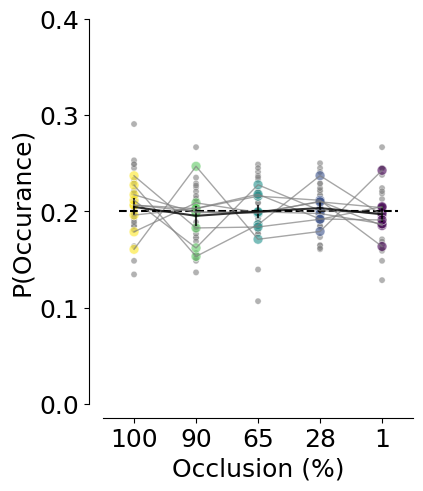

In [80]:
# Occurance of the different conditions
counts = (
    big_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    big_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(4, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_multi_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.2,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 0.4)
plt.xlim(-0.5, 4.5)
plt.xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

plt.xlabel("Occlusion (%)")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure4_multi_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
for i in counts.probability.columns:
    print(
        f"{i}: ",
        np.mean(np.array(counts["probability"][i])),
        "std: ",
        np.std(np.array(counts["probability"][i])),
    )
    for j in counts.probability.columns:
        if i < j:
            stat = ttest_rel(
                np.array(counts["probability"][i]), np.array(counts["probability"][j])
            )
            print(f"{i}-{j}: {stat}")

2025-04-23 12:17:54,052::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:54,052::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:54,060::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:54,060::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-04-23 12:17:54,166::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=-3.728594259213624, pvalue=0.0009033077400505256, df=27)
3.0-6.0: TtestResult(statistic=-6.048077101914309, pvalue=1.864084927133366e-06, df=27)
3.0-8.48: TtestResult(statistic=-6.4883736026395695, pvalue=5.905066328821617e-07, df=27)
4.2-6.0: TtestResult(statistic=-2.5114781446884717, pvalue=0.018308331740237698, df=27)
4.2-8.48: TtestResult(statistic=-3.58678435555008, pvalue=0.001305876927049184, df=27)
6.0-8.48: TtestResult(statistic=-0.905840912750415, pvalue=0.3730331500409404, df=27)
12.0-3.0: TtestResult(statistic=6.204673930528979, pvalue=1.2359380552038116e-06, df=27)
12.0-4.2: TtestResult(statistic=3.626698230147818, pvalue=0.0011775940823249718, df=27)
12.0-6.0: TtestResult(statistic=1.043160594919374, pvalue=0.3061245378258728, df=27)
12.0-8.48: TtestResult(statistic=0.10904169213783925, pvalue=0.9139757967863464, df=27)
              mean       sem
aperture                    
12.0      0.925335  0.012671
3.0       0.718456  0.028165
4.2    

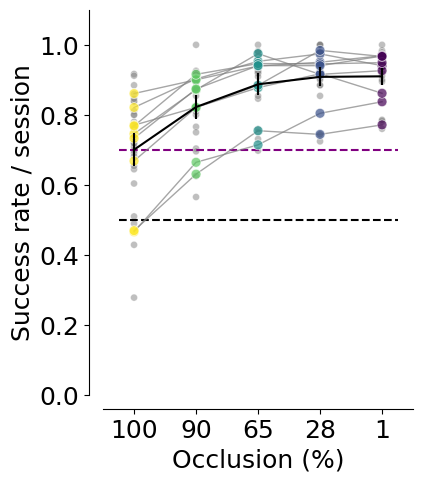

In [81]:
# Success rate per mouse (new)
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=big_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(big_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Success rate / session")
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure4_multi_occluder_rewards.svg", transparent=True)

In [82]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df[big_df.iti == 0.0].copy()
j_shaped = analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)

mean_mouse = (
    j_shaped.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
    )
    .mean(numeric_only=True)
    .copy()
)

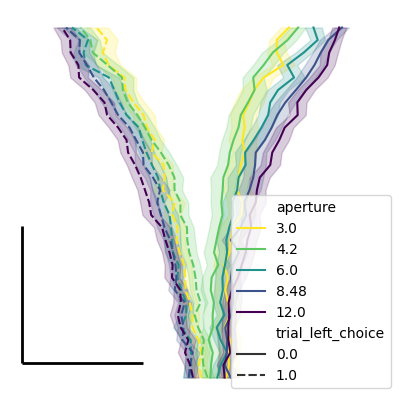

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x=mean_mouse.bin_centers,
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice
    if len(mean_mouse.aperture.unique()) == 2
    else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis("off")
#ax.legend([], [], frameon=False)
sns.despine(offset=10)
#plt.savefig(
#    save_fig_path + "figure4_multi_occluder_mean_trajectories.svg", transparent=True
#)

In [40]:
j_shaped = utils.create_bins(
    data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y"
)
j_shaped = j_shaped
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped["x_flipped"] = j_shaped.x * j_shaped.flip_one_side
mean_mouse = (
    j_shaped.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)
mean_mouse = (
    mean_mouse.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

In [41]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

ValueError: Data is unbalanced.

**Interpretation**

Since all p-values are very small (0.0000), we can conclude that both aperture and bin_centers significantly influence x_flipped, and their interaction is also significant. This means that the effect of aperture on x_flipped depends on bin_centers.

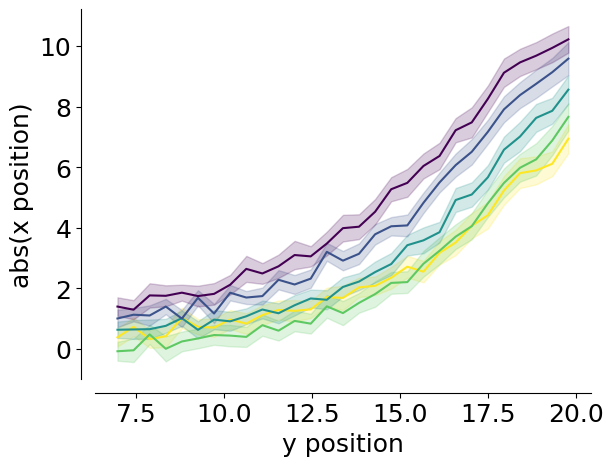

In [46]:
sns.lineplot(
    data=mean_mouse,
    x="bin_centers",
    y="x_flipped",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
    alpha=1,
)

plt.ylabel("abs(x position)")
plt.xlabel("y position")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure4_position_flipped.svg", transparent=True)

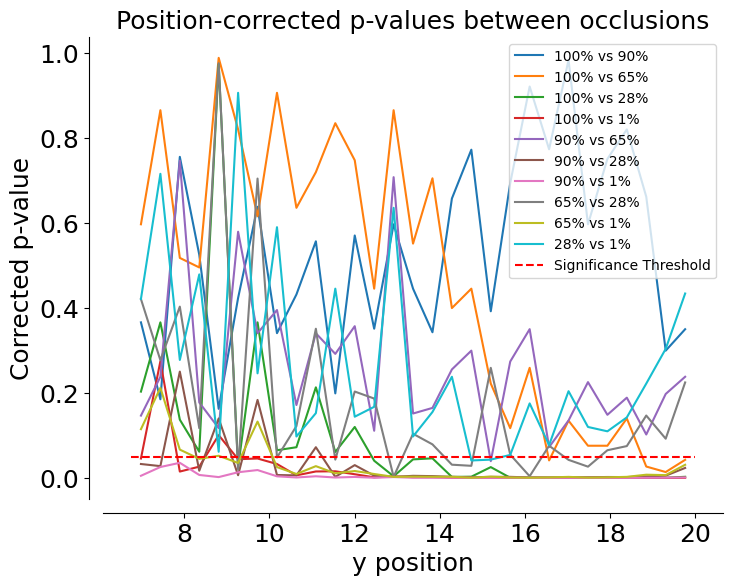

In [42]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.stats.multitest as smm

p_values = []
apertures = mean_mouse.aperture.unique()
percentage_pairs = ["100%", "90%", "65%", "28%", "1%"]

pairwise_comparisons = list(
    itertools.combinations(apertures, 2)
)  # Generate all pairs of apertures
pairwise_percentage = list(
    itertools.combinations(percentage_pairs, 2)
)  # Generate all pairs of apertures

for i in mean_mouse.bin_centers.unique():
    section = mean_mouse[mean_mouse.bin_centers == i]

    for ap1, ap2 in pairwise_comparisons:
        t = ttest_ind(
            section[section.aperture == ap1].x_flipped,
            section[section.aperture == ap2].x_flipped,
        )

        p_values.append(
            pd.DataFrame(
                {"segment": i, "aperture_pair": f"{ap1} vs {ap2}", "p_value": t.pvalue},
                index=[0],
            )
        )

# Convert to DataFrame
p_value_df = pd.concat(p_values)

# Apply False Discovery Rate (FDR) correction across all comparisons
p_value_df["p_value_corr"] = smm.multipletests(p_value_df.p_value, method="fdr_bh")[1]

# Plot results for each aperture pair
plt.figure(figsize=(8, 6))
for pair, label_pair in zip(pairwise_comparisons, pairwise_percentage):
    subset = p_value_df[p_value_df.aperture_pair == f"{pair[0]} vs {pair[1]}"]
    plt.plot(
        subset.segment, subset.p_value_corr, label=f"{label_pair[0]} vs {label_pair[1]}"
    )

plt.hlines(
    0.05,
    xmin=6.75,
    xmax=20,
    color="red",
    linestyle="dashed",
    label="Significance Threshold",
)
plt.xlabel("y position")
plt.ylabel("Corrected p-value")
plt.title("Position-corrected p-values between occlusions")
plt.legend()
sns.despine(offset=10)
plt.savefig(save_fig_path + "figure4_position_pvalue.svg", transparent=True)
plt.show()

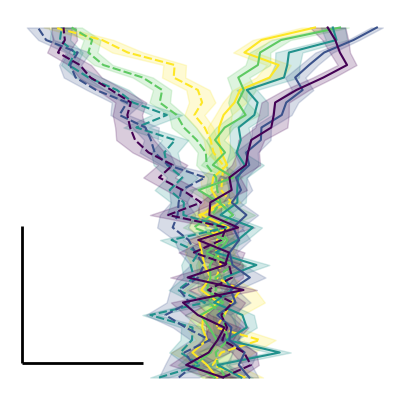

In [44]:
# Example

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotting.lineplot_flip_axis(
    data=j_shaped[j_shaped.dataset == "Kiwi_2024-08-19_1"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1]
    if len(mean_mouse.aperture.unique()) == 2
    else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16, 16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)

ax.legend([], [], frameon=False)
plt.axis("off")
plt.savefig(
    save_fig_path + "figure4_multi_occluder_trajectories_example_session.svg",
    transparent=True,
)